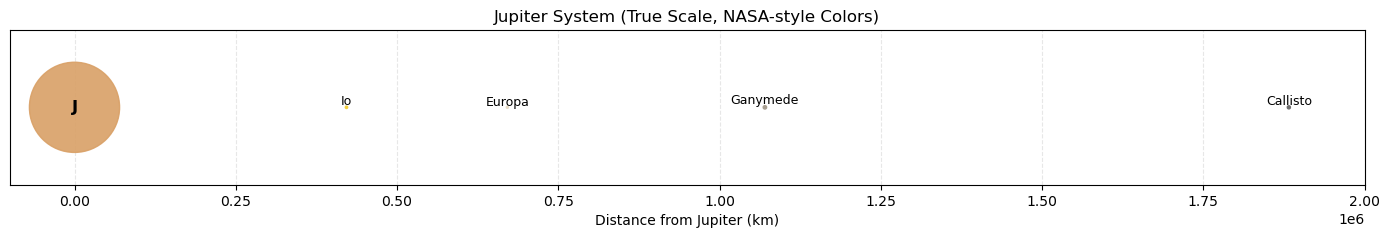

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u

# -----------------------------
# NASA-inspired colors
# -----------------------------
colors = {
    "Jupiter": "#d9a066",   # tan/orange
    "Io": "#f4d03f",        # yellow sulfur
    "Europa": "#e8dcc6",    # icy beige
    "Ganymede": "#a89f91",  # gray-brown
    "Callisto": "#6e6e6e",  # dark gray
}

# -----------------------------
# Real data
# -----------------------------
bodies = {
    "Jupiter": {"radius": 69911 * u.km, "distance": 0 * u.km},
    "Io": {"radius": 1821.6 * u.km, "distance": 421700 * u.km},
    "Europa": {"radius": 1560.8 * u.km, "distance": 671100 * u.km},
    "Ganymede": {"radius": 2634.1 * u.km, "distance": 1070400 * u.km},
    "Callisto": {"radius": 2410.3 * u.km, "distance": 1882700 * u.km},
}

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 6))

# Jupiter (TRUE circle)
jupiter_radius = bodies["Jupiter"]["radius"].to_value(u.km)

jupiter = plt.Circle(
    (0, 0),
    jupiter_radius,
    color=colors["Jupiter"],
    alpha=0.9,
    zorder=2
)
ax.add_patch(jupiter)

# Label Jupiter
ax.text(0, 0, "J", ha="center", va="center", fontsize=12, weight="bold", color="black")

# -----------------------------
# Plot moons
# -----------------------------
for name, data in bodies.items():
    if name == "Jupiter":
        continue

    dist = data["distance"].to_value(u.km)
    radius = data["radius"].to_value(u.km)

    moon = plt.Circle(
        (dist, 0),
        radius,
        color=colors[name],
        zorder=3
    )
    ax.add_patch(moon)

    ax.text(dist, radius * 2, name, ha="center", fontsize=9)

# -----------------------------
# Styling
# -----------------------------
ax.set_xlim(-100000, 2000000)
ax.set_ylim(-120000, 120000)

# 🔥 THIS FIXES THE ELLIPSE ISSUE
ax.set_aspect('equal', adjustable='box')

ax.set_yticks([])
ax.set_xlabel("Distance from Jupiter (km)")
ax.set_title("Jupiter System (True Scale, NASA-style Colors)")

ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

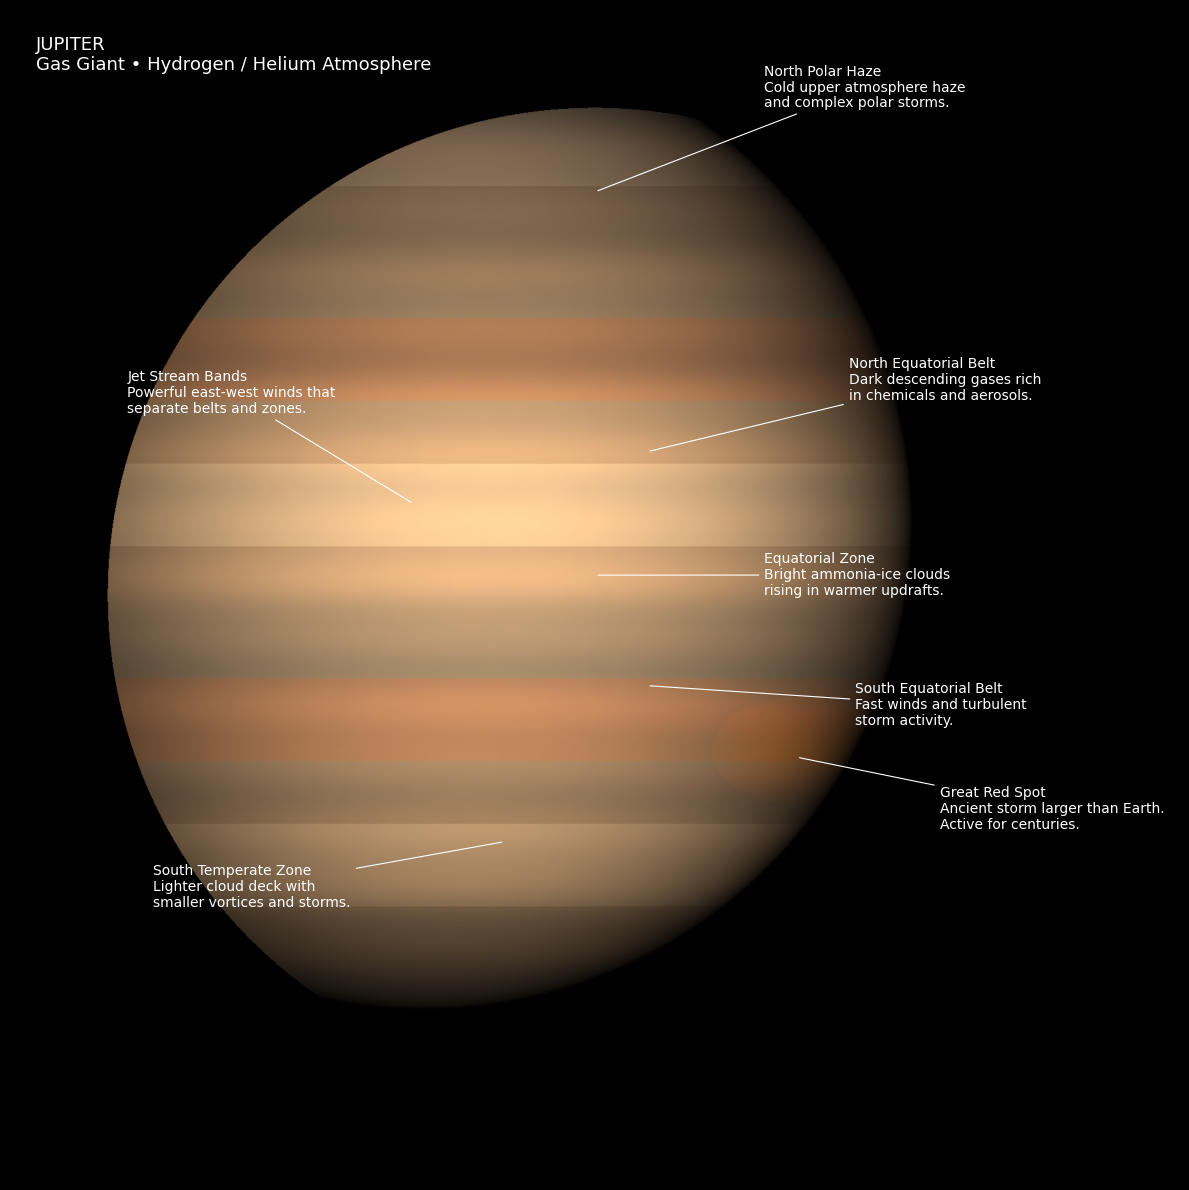

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# ==================================================
# REALISTIC JUPITER WITH LABELED FEATURES + DESCRIPTIONS
# ==================================================

np.random.seed(42)

size = 1800
x = np.linspace(-1.2, 1.2, size)
y = np.linspace(-1.2, 1.2, size)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)

mask = R <= 1.0

# --------------------------------------------------
# Sphere lighting
# --------------------------------------------------
light = np.clip(1 - ((X + 0.35)**2 + (Y - 0.15)**2), 0, 1)
light = light**0.55

# --------------------------------------------------
# Cloud bands
# --------------------------------------------------
lat = Y * 8.5

bands = (
    0.55
    + 0.18*np.sin(lat)
    + 0.10*np.sin(lat*2.5 + 0.8)
    + 0.06*np.sin(lat*5.8)
)

noise1 = gaussian_filter(np.random.normal(size=(size, size)), sigma=9)
noise2 = gaussian_filter(np.random.normal(size=(size, size)), sigma=20)

texture = bands + 0.12*noise1 + 0.06*noise2
texture = (texture - texture.min()) / (texture.max() - texture.min())

# --------------------------------------------------
# RGB colors
# --------------------------------------------------
rgb = np.zeros((size, size, 3))

rgb[:,:,0] = 0.72 + texture*0.35
rgb[:,:,1] = 0.60 + texture*0.22
rgb[:,:,2] = 0.46 + texture*0.12

# Bright zones
zones = (np.sin(lat) > 0.75).astype(float)
rgb[:,:,0] += zones*0.12
rgb[:,:,1] += zones*0.12
rgb[:,:,2] += zones*0.10

# Dark belts
belts = (np.sin(lat+0.6) < -0.75).astype(float)
rgb[:,:,0] += belts*0.08
rgb[:,:,1] -= belts*0.03
rgb[:,:,2] -= belts*0.06

# --------------------------------------------------
# Great Red Spot
# --------------------------------------------------
x0, y0 = 0.42, -0.32
a, b = 0.18, 0.11

grs = (((X-x0)/a)**2 + ((Y-y0)/b)**2) <= 1.0
edge = np.exp(-(((X-x0)/a)**2 + ((Y-y0)/b)**2)*1.8)

rgb[:,:,0] += grs*0.30*edge
rgb[:,:,1] += grs*0.07*edge
rgb[:,:,2] -= grs*0.10*edge

swirl = np.exp(-(((X-x0)/0.28)**2 + ((Y-y0)/0.18)**2))
rgb[:,:,0] += 0.06*swirl*np.sin(45*Y)

# --------------------------------------------------
# Polar haze
# --------------------------------------------------
polar = np.clip((np.abs(Y)-0.72)/0.3, 0, 1)
rgb[:,:,2] += polar*0.10
rgb[:,:,1] += polar*0.04

# --------------------------------------------------
# Shading
# --------------------------------------------------
rgb *= light[:,:,None]
rgb *= np.clip(1 - (R**2)*0.35, 0.55, 1.0)[:,:,None]

rgb[~mask] = 0
rgb = np.clip(rgb, 0, 1)

# ==================================================
# Plot
# ==================================================
fig, ax = plt.subplots(figsize=(14,12), facecolor="black")
ax.imshow(rgb, origin="lower")
ax.axis("off")
ax.set_facecolor("black")

# --------------------------------------------------
# Label helper
# --------------------------------------------------
def label(txt, xy, xytext):
    ax.annotate(
        txt,
        xy=xy,
        xytext=xytext,
        color="white",
        fontsize=10,
        linespacing=1.15,
        arrowprops=dict(arrowstyle="-", lw=0.8, color="white")
    )

# ==================================================
# Labels + Descriptions
# ==================================================

label(
    "North Polar Haze\nCold upper atmosphere haze\nand complex polar storms.",
    (900, 1520), (1160, 1650)
)

label(
    "North Equatorial Belt\nDark descending gases rich\nin chemicals and aerosols.",
    (980, 1120), (1290, 1200)
)

label(
    "Equatorial Zone\nBright ammonia-ice clouds\nrising in warmer updrafts.",
    (900, 930), (1160, 900)
)

label(
    "South Equatorial Belt\nFast winds and turbulent\nstorm activity.",
    (980, 760), (1300, 700)
)

label(
    "Great Red Spot\nAncient storm larger than Earth.\nActive for centuries.",
    (1210, 650), (1430, 540)
)

label(
    "Jet Stream Bands\nPowerful east-west winds that\nseparate belts and zones.",
    (620, 1040), (180, 1180)
)

label(
    "South Temperate Zone\nLighter cloud deck with\nsmaller vortices and storms.",
    (760, 520), (220, 420)
)

# --------------------------------------------------
# Title
# --------------------------------------------------
ax.text(
    40, 1760,
    "JUPITER\nGas Giant • Hydrogen / Helium Atmosphere",
    color="white",
    fontsize=13,
    ha="left",
    va="top"
)

plt.tight_layout()
plt.show()